# ADMIXTURE Analysis of 1000 Genomes Low-Coverage Data

**Course:** Population Genomics and Population Structure Analysis  
**Instructor:** Nikolay Oskolkov  
**Platform:** Google Colab

---

In this notebook we will:

1. Install **Conda**, **ANGSD**, **PLINK**, **ADMIXTURE**, and **R** in Google Colab.
2. Mount **Google Drive** to access the BAM files of the 1000 Genomes Project.
3. Prepare the BAM file list with Colab-compatible paths.
4. Produce **hard genotype calls** from low-coverage data in **PLINK format** using ANGSD.
5. Convert the TPED/TFAM files to binary PLINK format (**BED/BIM/FAM**) with PLINK.
6. Run **ADMIXTURE** for K = 3 as a first test.
7. Run **cross-validation** for K = 2..8 and choose the best K.
8. Plot the admixture proportions with a custom **R script** producing a landscape 3-panel PDF (K = 3, 4, 5) and display it inline.

**Input data:** 435 low-coverage BAM files from the 1000 Genomes Project, located in your Google Drive at `PopGen_PopStructure/1000G/smallbams/`.

## 1. Install Conda in Google Colab

Google Colab does not ship with Conda by default. We use the `condacolab` package, which installs a lightweight Miniconda environment directly inside the notebook.

> ⚠️ **Important:** After running the cell below, the Colab kernel will **restart automatically**. This is expected — just continue with the next cell once the restart finishes.

In [1]:
# Install Conda inside Google Colab
!pip install -q condacolab
import condacolab
condacolab.install()


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/26.3.2-3/Miniforge3-26.3.2-3-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:12
🔁 Restarting kernel...


## 2. Install ANGSD, PLINK, and ADMIXTURE

We install three tools from **Bioconda**:

| Tool | Purpose |
|---|---|
| **ANGSD** | Genotype likelihood computation and genotype calling from low-coverage BAM files |
| **PLINK 1.9** | Conversion between PLINK text (TPED/TFAM) and binary (BED/BIM/FAM) formats |
| **ADMIXTURE** | Maximum-likelihood estimation of individual ancestry proportions |

The installations may take a minute or two.

In [2]:
# Install ANGSD, PLINK, and ADMIXTURE from Bioconda
!conda install -y bioconda::angsd
!conda install -y bioconda::plink
!conda install -y bioconda::admixture

Retrieving notices: - \ done
Channels:
 - conda-forge
 - bioconda
Platform: linux-64
Solving environment: \ | / - done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - bioconda::angsd


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _python_abi3_support-1.0   |       hd8ed1ab_3           8 KB  conda-forge
    angsd-0.940                |       h13024bc_4         631 KB  bioconda
    annotated-types-0.8.0      |     pyhd8ed1ab_0          19 KB  conda-forge
    anyio-4.15.1               |     pyh5ded981_1         171 KB  conda-forge
    ca-certificates-2026.7.22  |       hbd8a1cb_0         129 KB  conda-forge
    cached-property-2.0.1      |     pyhcf101f3_0           4 KB  conda-forge
    cached_property-2.0.1      |     pyhcf101f3_0          16 KB  conda-forge
    certifi-2026.7.22          |     pyhd8ed1ab_0         134 KB  conda-forg

### 2.1 Verify the installation

Let us confirm all three tools are available and print their versions.

In [1]:
!angsd --version 2>&1 | head -n 3

	-> angsd version: 0.940-dirty (htslib: 1.23.1) build(Dec 15 2024 09:11:59)
	-> angsd --version 



In [2]:
!plink --version

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)


In [3]:
!admixture --version 2>&1 | head -n 3

****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****


## 3. Mount Google Drive

We will store the input BAM files and all output files on Google Drive, so that the analysis results persist between Colab sessions.

Running the cell below will open a Google authorization dialog. Grant access to your Drive, then return to the notebook.

In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 4. Set the Working Directory

We change the working directory to the 1000G project folder on Google Drive. All outputs will be written there.

In [5]:
import os

# Change working directory to the 1000G project folder on Google Drive
os.chdir("/content/drive/MyDrive/PopGen_PopStructure/1000G")

# Confirm we are in the right place
!pwd
!ls -lh

/content/drive/MyDrive/PopGen_PopStructure/1000G
total 4.3M
-rw------- 1 root root 8.3K Sep 29 14:52 1000G.arg
-rw------- 1 root root  53K Sep 29 14:38 1000G_bam_list_backup.txt
-rw------- 1 root root  53K Sep 29 15:23 1000G_bam_list.regererated.txt
-rw------- 1 root root  44K Sep 29 14:38 1000G_bam_list.txt
-rw------- 1 root root 2.2M Sep 29 14:52 1000G.beagle.gz
-rw------- 1 root root  42K Sep 27 14:47 1000G.fopt.gz
-rw------- 1 root root  471 Sep 27 14:47 1000G.log
-rw------- 1 root root  13K Sep 29 14:52 1000G.mafs.gz
-rw------- 1 root root  30K Sep 27 14:47 1000G.qopt
drwx------ 2 root root 4.0K Sep 28 10:20 bams
drwx------ 2 root root 4.0K Sep 27 05:23 beagle
drwx------ 2 root root 4.0K Sep 28 10:20 hg38
-rw------- 1 root root 2.0M Sep 29 15:13 pca_1000G.cov
-rw------- 1 root root  398 Sep 29 15:13 pca_1000G.log
drwx------ 2 root root 4.0K Sep 28 10:20 QC_after_adapter_removal
drwx------ 2 root root 4.0K Sep 28 10:20 QC_before_adapter_removal
drwx------ 2 root root 4.0K Sep 27 05

## 5. Check the BAM File List

We expect a file called `1000G_bam_list.txt` containing one absolute path per BAM file. Let us inspect the first few lines.

In [9]:
!head 1000G_bam_list.txt

/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA19752.mapped.ILLUMINA.bwa.MXL.low_coverage.20130415.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA12234.mapped.ILLUMINA.bwa.CEU.low_coverage.20130415.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA18636.mapped.ILLUMINA.bwa.CHB.low_coverage.20130415.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA11995.mapped.ILLUMINA.bwa.CEU.low_coverage.20120522.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA19152.mapped.ILLUMINA.bwa.YRI.low_coverage.20120522.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA12005.mapped.ILLUMINA.bwa.CEU.low_coverage.20120522.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA18545.mapped.ILLUMINA.bwa.CHB.low_coverage.20130415.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA18631.mapped.ILLUMINA.bwa.CHB.low_coverage.20120522.bam
/content/drive/M

In [7]:
!wc -l 1000G_bam_list.txt

435 1000G_bam_list.txt


## 6. Produce Genotype Calls in PLINK Format with ANGSD

We now run ANGSD on all 435 BAM files to produce **hard genotype calls** in PLINK format. This is required by ADMIXTURE, which does not accept genotype likelihoods directly.

Key parameters:

| Flag | Meaning |
|---|---|
| `-bam` | List of BAM files |
| `-GL 2` | GATK genotype likelihood model |
| `-doMajorMinor 1` | Infer major/minor alleles from genotype likelihoods |
| `-doMaf 1` | Estimate allele frequencies |
| `-SNP_pval 2e-6` | Keep only significantly variable sites |
| `-minMapQ 30` | Minimum mapping quality |
| `-minQ 20` | Minimum base quality |
| `-minInd 25` | Minimum number of individuals with data |
| `-minMaf 0.05` | Minimum minor allele frequency |
| `-doPost 1` | Use allele frequency as prior for genotype calling |
| `-doPlink 2` | Write PLINK output (TPED/TFAM) |
| `-doGeno 2` | Call genotypes coded 0/1/2 from the major allele |
| `-out 1000G_admix` | Output prefix |
| `-P 5` | Use 5 threads |

> ⚠️ **Note:** Calling hard genotypes from low-coverage data introduces bias. ANGSD developers recommend using genotype likelihoods directly (e.g. with NGSadmix). We do it here because ADMIXTURE requires hard calls. Interpret the results accordingly.

In [10]:
!angsd -bam 1000G_bam_list.txt \
       -GL 2 -doMajorMinor 1 -doMaf 1 -SNP_pval 2e-6 \
       -minMapQ 30 -minQ 20 -minInd 25 -minMaf 0.05 \
       -doPost 1 -doPlink 2 -doGeno 2 \
       -out 1000G_admix -P 5

	-> angsd version: 0.940-dirty (htslib: 1.23.1) build(Dec 15 2024 09:11:59)
	-> angsd -bam 1000G_bam_list.txt -GL 2 -doMajorMinor 1 -doMaf 1 -SNP_pval 2e-6 -minMapQ 30 -minQ 20 -minInd 25 -minMaf 0.05 -doPost 1 -doPlink 2 -doGeno 2 -out 1000G_admix -P 5 
	-> Inputtype is BAM/CRAM
[multiReader] 435 samples in 435 input files
	-> SNP-filter using a pvalue: 2.000000e-06 correspond to 22.595043 likelihood units
	-> Parsing 435 number of samples 

	-> Allocated ~ 10 million nodes to the nodepool, this is not an estimate of the memory usage

	-> Allocated ~ 20 million nodes to the nodepool, this is not an estimate of the memory usage

	-> Allocated ~ 30 million nodes to the nodepool, this is not an estimate of the memory usage

	-> Allocated ~ 40 million nodes to the nodepool, this is not an estimate of the memory usage

	-> Allocated ~ 50 million nodes to the nodepool, this is not an estimate of the memory usage

	-> Allocated ~ 60 million nodes to the nodepool, this is not an estimate of t

### 6.1 Inspect the ANGSD output

ANGSD should produce at minimum:

- `1000G_admix.tped` and `1000G_admix.tfam` (PLINK text format)
- `1000G_admix.geno.gz` (genotype calls, human-readable)
- `1000G_admix.mafs.gz` (estimated allele frequencies)

In [11]:
!ls -lh 1000G_admix.*

-rw------- 1 root root 9.5K Sep 30 11:10 1000G_admix.arg
-rw------- 1 root root 158K Sep 30 11:10 1000G_admix.geno.gz
-rw------- 1 root root  13K Sep 30 11:10 1000G_admix.mafs.gz
-rw------- 1 root root 6.3K Sep 30 11:07 1000G_admix.tfam
-rw------- 1 root root 2.2M Sep 30 11:10 1000G_admix.tped


## 7. Convert PLINK Text Format to Binary Format

ANGSD writes PLINK **transposed** text files (`.tped` + `.tfam`). ADMIXTURE requires the PLINK **binary** format (`.bed` + `.bim` + `.fam`).

We use `plink --tfile ... --make-bed` to perform the conversion. PLINK handles this automatically and also produces summary statistics such as genotyping rate.

In [12]:
!plink --tfile 1000G_admix --make-bed --out 1000G_admix

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to 1000G_admix.log.
Options in effect:
  --make-bed
  --out 1000G_admix
  --tfile 1000G_admix

12975 MB RAM detected; reserving 6487 MB for main workspace.
Processing .tped file... done.
1000G_admix-temporary.bed + 1000G_admix-temporary.bim +
1000G_admix-temporary.fam written.
1306 variants loaded from .bim file.
435 people (0 males, 0 females, 435 ambiguous) loaded from .fam.
Ambiguous sex IDs written to 1000G_admix.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 435 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44

### 7.1 Check the binary PLINK files

We expect three files: `1000G_admix.bed`, `1000G_admix.bim`, and `1000G_admix.fam`.

In [13]:
!ls -lh 1000G_admix.bed 1000G_admix.bim 1000G_admix.fam

-rw------- 1 root root 140K Sep 30 11:10 1000G_admix.bed
-rw------- 1 root root  37K Sep 30 11:10 1000G_admix.bim
-rw------- 1 root root 6.3K Sep 30 11:10 1000G_admix.fam


## 8. Run ADMIXTURE for K = 3

We run ADMIXTURE on the binary PLINK file for K = 3 ancestral populations, using 20 threads and cross-validation (`--cv`).

ADMIXTURE will produce:

- `1000G_admix.3.Q` — ancestry proportions per individual
- `1000G_admix.3.P` — allele frequencies per ancestral population
- A cross-validation error value printed to stdout

The cross-validation error is what we will use to choose the best K.

In [14]:
!admixture 1000G_admix.bed 3 -j20 --cv

****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Parallel execution requested.  Will use 20 threads.
Cross-validation will be performed.  Folds=5.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 435x1306
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 0.036	Loglikelihood: -534888	(delta): 292752
2 (E

## 9. Cross-Validation Across K = 2..8

We now run ADMIXTURE for **K = 2 through 8** and collect the cross-validation (CV) error from each run. The K with the lowest CV error is our best estimate of the number of ancestral populations.

Each run writes its own log file (`admix_K2.log`, `admix_K3.log`, ...) and its own `.Q` and `.P` files (e.g. `1000G_admix.4.Q`, `1000G_admix.4.P`).

In [16]:
%%bash

for K in 2 3 4 5 6 7 8; do
    echo "Running ADMIXTURE for K = $K ..."
    admixture 1000G_admix.bed $K -j20 --cv > admix_K${K}.log
    grep "CV error" admix_K${K}.log
done

echo "All ADMIXTURE runs finished."

Running ADMIXTURE for K = 2 ...
CV error (K=2): 0.55261
Running ADMIXTURE for K = 3 ...
CV error (K=3): 0.52883
Running ADMIXTURE for K = 4 ...
CV error (K=4): 0.52680
Running ADMIXTURE for K = 5 ...
CV error (K=5): 0.52529
Running ADMIXTURE for K = 6 ...
CV error (K=6): 0.52452
Running ADMIXTURE for K = 7 ...
CV error (K=7): 0.52448
Running ADMIXTURE for K = 8 ...
CV error (K=8): 0.52432
All ADMIXTURE runs finished.


### 9.1 Inspect the CV errors

Let us print the CV error for each K side by side. The best K is usually the one with the lowest CV error, or where the CV curve reaches a clear elbow.

In [17]:
%%bash

for K in 2 3 4 5 6 7 8; do
    err=$(grep "CV error" admix_K${K}.log | awk '{print $NF}')
    echo "K = $K  ->  CV error = $err"
done

K = 2  ->  CV error = 0.55261
K = 3  ->  CV error = 0.52883
K = 4  ->  CV error = 0.52680
K = 5  ->  CV error = 0.52529
K = 6  ->  CV error = 0.52452
K = 7  ->  CV error = 0.52448
K = 8  ->  CV error = 0.52432


## 10. Prepare the BAM List for the R Plotting Script

The R script parses population labels directly from the BAM file paths. We confirm that `1000G_bam_list.txt` is present in the working directory, since the R chunk will read it.

In [18]:
!ls -lh 1000G_bam_list.txt

-rw------- 1 root root 53K Sep 30 11:00 1000G_bam_list.txt


## 11. Plot Admixture Proportions in R

We now write a small R script that:

1. Reads the population labels from `1000G_bam_list.txt`.
2. Reads the ADMIXTURE `.Q` files for K = 3, 4, and 5.
3. Sorts individuals first by population, then by dominant ancestry component.
4. Draws three stacked barplots (**K = 3, 4, 5**) as panels of a single landscape figure.
5. Saves the figure as `1000G_admix_results.pdf` and also as a PNG for inline display in Colab.

We use `cairo_pdf()` for UTF-8-safe PDF output.

In [19]:
%%writefile plot_admixture_multiK.R
# =============================================================
# Multi-K ADMIXTURE barplot -> landscape PDF + PNG (for Colab)
# =============================================================

# -----------------------------
# 1. Parameters
# -----------------------------
K_values <- c(3, 4, 5)
bamlist  <- "1000G_bam_list.txt"
out_pdf  <- "1000G_admix_results.pdf"
out_png  <- "1000G_admix_results.png"

pop_order <- c("YRI", "ASW", "CEU", "MXL", "CHB")

palette_cols <- c("#E24A5A", "#63C24A", "#4A90E2", "#F5A623", "#9B59B6",
                  "#1ABC9C", "#E67E22", "#34495E")

# -----------------------------
# 2. Read population labels
# -----------------------------
pops <- readLines(bamlist)
pops <- sapply(strsplit(pops, "\\."), function(x) x[6])
pops <- factor(pops, levels = pop_order)

# -----------------------------
# 3. Helper: read Q, order individuals
# -----------------------------
prepare_Q <- function(K) {
    qfile <- paste0("1000G_admix.", K, ".Q")
    Q <- as.matrix(read.table(qfile))
    colnames(Q) <- paste0("Pop", seq_len(ncol(Q)))

    dom <- apply(Q, 1, which.max)
    ord <- order(pops, dom, -apply(Q, 1, max))

    list(Q = Q[ord, , drop = FALSE],
         pops = pops[ord],
         K = K)
}

# -----------------------------
# 4. Helper: draw one panel
# -----------------------------
plot_admix_panel <- function(obj, show_xlab = FALSE, show_legend = TRUE) {
    Q    <- obj$Q
    pops <- obj$pops
    K    <- obj$K

    bp <- barplot(
        t(Q),
        col    = palette_cols[seq_len(K)],
        border = NA,
        space  = 0,
        las    = 2,
        ylab   = "Admixture proportions",
        ylim   = c(0, 1),
        xaxt   = "n",
        main   = paste0("ADMIXTURE K = ", K)
    )

    pop_levels  <- levels(pops)
    pop_centers <- sapply(pop_levels, function(p) mean(bp[pops == p]))

    text(x = pop_centers, y = -0.06, labels = pop_levels, xpd = NA, cex = 1.0)

    boundaries <- cumsum(table(pops))
    boundaries <- boundaries[-length(boundaries)]
    if (length(boundaries) > 0) {
        abline(v = bp[boundaries + 1] - 0.5, col = "black", lwd = 1.2)
    }

    if (show_xlab) mtext("Individuals", side = 1, line = 3.2, cex = 1.0)

    if (show_legend) {
        legend("topright",
               legend = colnames(Q),
               fill   = palette_cols[seq_len(K)],
               border = NA,
               bty    = "n",
               cex    = 0.85)
    }
}

# -----------------------------
# 5. Build the figure
# -----------------------------
draw_all <- function() {
    par(mfrow = c(length(K_values), 1),
        mar   = c(3.5, 5, 3, 2),
        oma   = c(1, 0, 2, 0))
    for (i in seq_along(K_values)) {
        obj <- prepare_Q(K_values[i])
        plot_admix_panel(obj,
                         show_xlab   = (i == length(K_values)),
                         show_legend = TRUE)
    }
    mtext("1000 Genomes Project - ADMIXTURE results",
          side = 3, outer = TRUE, line = 0.5,
          cex = 1.3, font = 2)
}

# PDF (landscape)
cairo_pdf(out_pdf, width = 14, height = 10)
draw_all()
dev.off()

# PNG (for inline display in the notebook)
png(out_png, width = 1400, height = 1000, res = 120)
draw_all()
dev.off()

cat("Done. Written:", out_pdf, "and", out_png, "\n")

Writing plot_admixture_multiK.R


### 11.1 Run the R plotting script

We execute the script with `Rscript`. It writes both the PDF and a PNG version of the landscape figure.

In [20]:
!Rscript plot_admixture_multiK.R

null device 
          1 
null device 
          1 
Done. Written: 1000G_admix_results.pdf and 1000G_admix_results.png 


### 11.2 Display the figure inline

We use `IPython.display.Image` to show the PNG inside the notebook.

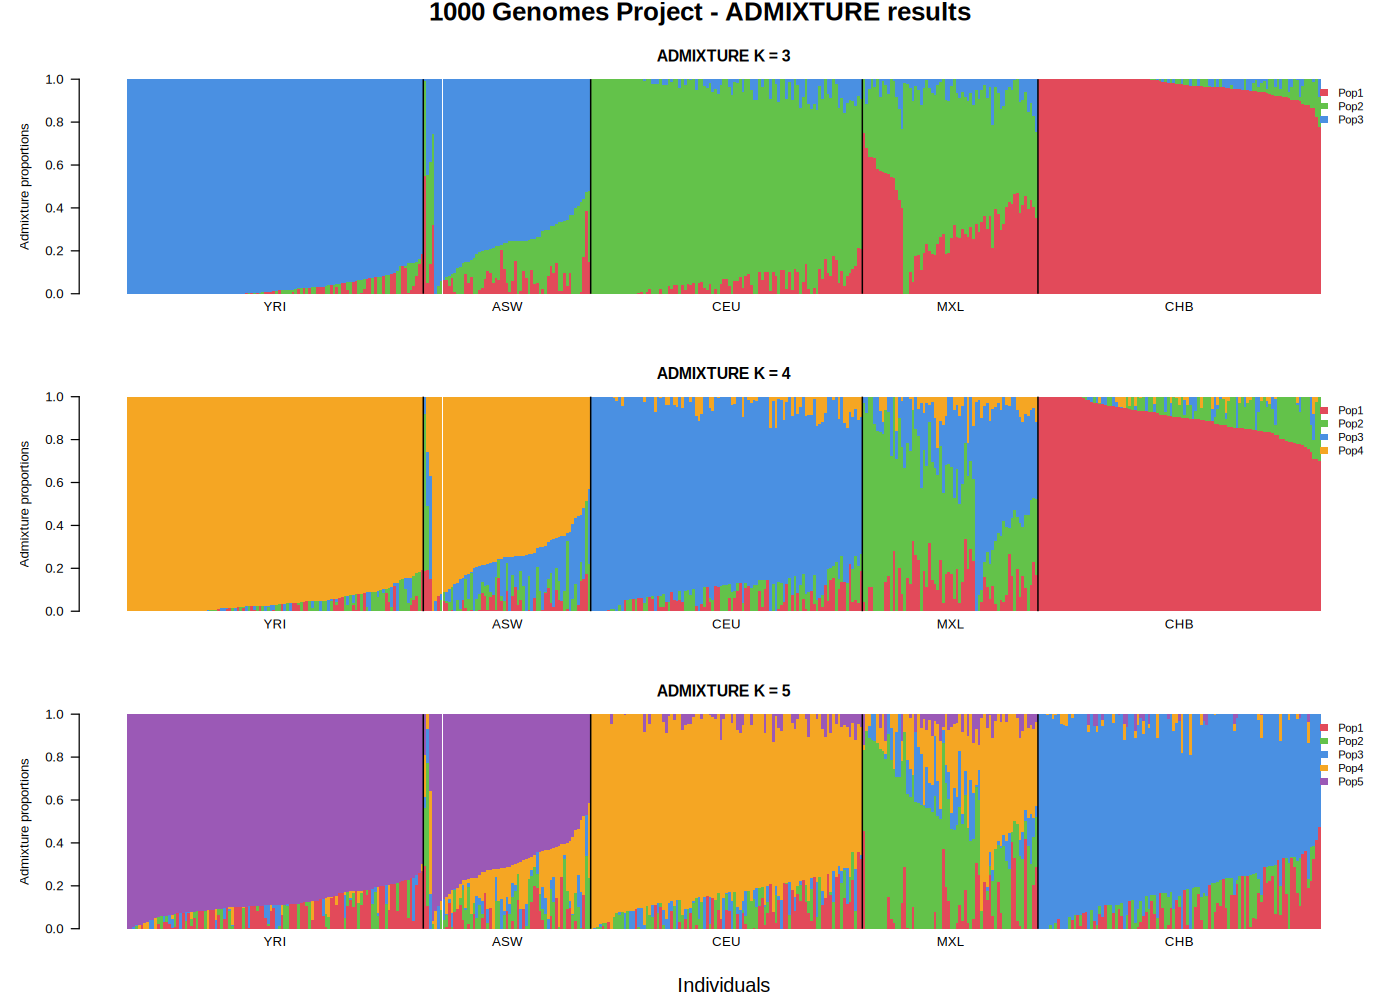

In [21]:
from IPython.display import Image, display

display(Image(filename="1000G_admix_results.png"))

## 12. Summary

In this notebook we:

✅ Installed **Conda**, **ANGSD**, **PLINK**, and **ADMIXTURE** in Google Colab.  
✅ Mounted **Google Drive** to access the 1000 Genomes BAM files.  
✅ Called hard genotypes with **ANGSD** and wrote PLINK text files (`1000G_admix.tped/.tfam`).  
✅ Converted the text files to PLINK binary format with **PLINK** (`1000G_admix.bed/.bim/.fam`).  
✅ Ran **ADMIXTURE** for K = 3 and for K = 2..8 with cross-validation.  
✅ Selected the best K by inspecting the CV error curve.  
✅ Plotted the admixture proportions for K = 3, 4, 5 with a custom **R script**.  
✅ Displayed the resulting landscape figure inline.

### Next steps

- Try **NGSadmix** directly on the ANGSD Beagle file (`1000G.beagle.gz`) for a more statistically appropriate analysis of low-coverage data.
- Compute **Fst** between inferred ancestral populations using the `.P` files from ADMIXTURE or with ANGSD `realSFS`.
- Compare ADMIXTURE-inferred clusters with the known 1000G population labels (YRI, CEU, CHB, MXL, ASW) to assess how well ancestry is recovered.

### References

- Alexander, D. H., Novembre, J., & Lange, K. (2009). *Fast model-based estimation of ancestry in unrelated individuals.* Genome Research.  
- Korneliussen, T. S., Albrechtsen, A., & Nielsen, R. (2014). *ANGSD: Analysis of Next Generation Sequencing Data.* BMC Bioinformatics.  
- Meisner, J., & Albrechtsen, A. (2018). *Inferring population structure and admixture proportions in low-depth NGS data.* Genetics.

## 13. Render the Notebook as HTML

We now export this notebook to a standalone HTML file using `nbconvert`. The HTML includes all markdown, code, and outputs (including the inline admixture figure), so it can be shared with students who do not use Colab.

Because Colab does not automatically save the notebook to disk, we first save a copy of the current notebook to Google Drive with `%%javascript`, then run `nbconvert` on that saved file.

In [22]:
# ------------------------------------------------------------------
# 13. Convert this notebook to HTML as the last step
# ------------------------------------------------------------------
import os

# ----- 1. Ask Colab to save the current notebook to Drive -----------
# Colab exposes the notebook through the JS API. We use it to save
# the current notebook to a known path on Drive before conversion.
from google.colab import _message

# Path where the notebook is saved (change if you want a different location)
notebook_path = "/content/drive/MyDrive/PopGen_PopStructure/ADMIXTURE_Colab.ipynb"
html_path     = notebook_path.replace(".ipynb", ".html")

# Ask Colab to save the current notebook (same as File -> Save)
_message.blocking_request(
    "save_notebook",
    request={},
    timeout_sec=5,
)

print("Notebook saved by Colab to its default Drive location.")
print("Assuming the notebook path is:", notebook_path)

Notebook saved by Colab to its default Drive location.
Assuming the notebook path is: /content/drive/MyDrive/PopGen_PopStructure/ADMIXTURE_Colab.ipynb


In [ ]:
# ----- 2. Run nbconvert -------------------------------------------
# Convert the notebook on disk to a standalone HTML file.
!jupyter nbconvert --to html "$notebook_path"